## Multivariate Forecasting

with:- 

feature columns, 
lag features, 
rolling features, 
time features

and train:

# XGBoost or RandomForest

# Step For Random Forest Model to train and test data.
STEP 1 → Understand & Load Data

STEP 2 → Clean Data

STEP 3 → Feature Engineering

STEP 4 → Train/Test Split

STEP 5 → Train Random Forest

STEP 6 → Predict

STEP 7 → Accuracy Check

STEP 8 → Feature Importance

STEP 9 → Future Forecasting

STEP 10 → Advanced Tuning

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Data Loading 
raw_data = pd.read_csv('Energy_Dataset_ML.csv')
print(raw_data.shape)
raw_data.head()


(40952, 23)


,Time,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09,...,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,target
0,04/10/2024 12:00,0.0,0.0,0.0,119.290878,0.0,0.0,108.502075,134.461426,100.306824,...,101.537338,526.225403,950.598267,317.534698,87.328026,908.293213,831.583679,1493.268188,728.515625,1522.5
1,04/10/2024 12:15,0.0,0.0,0.0,119.224632,0.0,0.0,0.173611,0.404006,0.115741,...,87.574669,512.467468,924.710449,219.791656,85.734978,44.133453,21.282021,0.000000,776.747009,1895.0
2,04/10/2024 12:30,0.0,0.0,0.0,119.294258,0.0,0.0,100.112236,109.554970,0.115741,...,67.657333,523.296082,923.986328,158.854156,88.341782,35.701073,644.438171,0.000000,748.914978,2572.5
3,04/10/2024 12:45,0.0,0.0,0.0,119.451820,0.0,0.0,95.328934,137.838760,70.482636,...,94.453339,543.406433,937.504272,179.861099,85.807388,280.516205,726.837707,0.000000,775.173645,2652.5
4,04/10/2024 13:00,0.0,0.0,0.0,119.407585,0.0,0.0,85.291878,144.616455,90.254265,...,96.096001,540.641663,949.533142,278.645813,84.866043,848.549438,815.185974,1540.173706,789.008301,2650.0


In [3]:
print(raw_data.columns)

# data types Checking
raw_data.info()

Index(['Time', 'feature_01', 'feature_02', 'feature_03', 'feature_04',
       'feature_05', 'feature_06', 'feature_07', 'feature_08', 'feature_09',
       'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14',
       'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19',
       'feature_20', 'feature_21', 'target'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 40952 entries, 0 to 40951
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Time        40952 non-null  str    
 1   feature_01  40952 non-null  float64
 2   feature_02  40952 non-null  float64
 3   feature_03  40952 non-null  float64
 4   feature_04  40952 non-null  float64
 5   feature_05  40952 non-null  float64
 6   feature_06  40952 non-null  float64
 7   feature_07  40952 non-null  float64
 8   feature_08  40952 non-null  float64
 9   feature_09  40952 non-null  float64
 10  feature_10  40952 non-null  float64
 1

In [4]:
#checking for missing values
print(f"Total Missing Values:{raw_data.isnull().sum().sum()}\n \nEach Column:\n",raw_data.isnull().sum())

Total Missing Values:0
 
Each Column:
 Time          0
feature_01    0
feature_02    0
feature_03    0
feature_04    0
feature_05    0
feature_06    0
feature_07    0
feature_08    0
feature_09    0
feature_10    0
feature_11    0
feature_12    0
feature_13    0
feature_14    0
feature_15    0
feature_16    0
feature_17    0
feature_18    0
feature_19    0
feature_20    0
feature_21    0
target        0
dtype: int64


In [5]:
# Data Set Understanding like mean max and STD , othere parameter of the data set
raw_data.describe().T

,count,mean,std,min,25%,50%,75%,max
feature_01,40952.0,3902.156877,3273.622302,0.000000,0.000000,5230.995606,7016.287231,7960.601074
feature_02,40952.0,296.077828,195.739376,0.000000,0.000000,405.170288,439.703980,710.868530
feature_03,40952.0,152.886518,116.615331,0.000000,0.000000,191.872559,240.944824,559.914551
feature_04,40952.0,64.260022,47.732196,0.010820,16.053831,80.515156,110.621801,135.429352
feature_05,40952.0,120.809209,119.596579,0.000000,0.000000,59.266491,244.118912,300.000000
feature_06,40952.0,511.819294,333.285731,0.000000,0.000000,729.599976,742.400024,934.349976
feature_07,40952.0,76.340845,44.186931,0.115741,75.317356,96.166355,102.415964,200.000000
feature_08,40952.0,93.026896,55.513266,0.000000,53.427717,118.309258,134.888348,157.527710
feature_09,40952.0,86.606632,42.391359,0.096078,95.215353,105.227501,110.339472,200.000000
feature_10,40952.0,674.524511,356.913081,0.000000,128.000000,880.259003,900.078735,929.809082


In [6]:
# Time is present in str format so we need to convert it into datetime format
raw_data['Time'] = pd.to_datetime(raw_data['Time'])
data = raw_data.sort_values('Time').reset_index(drop=True)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 40952 entries, 0 to 40951
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Time        40952 non-null  datetime64[us]
 1   feature_01  40952 non-null  float64       
 2   feature_02  40952 non-null  float64       
 3   feature_03  40952 non-null  float64       
 4   feature_04  40952 non-null  float64       
 5   feature_05  40952 non-null  float64       
 6   feature_06  40952 non-null  float64       
 7   feature_07  40952 non-null  float64       
 8   feature_08  40952 non-null  float64       
 9   feature_09  40952 non-null  float64       
 10  feature_10  40952 non-null  float64       
 11  feature_11  40952 non-null  float64       
 12  feature_12  40952 non-null  float64       
 13  feature_13  40952 non-null  float64       
 14  feature_14  40952 non-null  float64       
 15  feature_15  40952 non-null  float64       
 16  feature_16  40952 non-null  float

In [7]:
# need to check Time range data Start and End time
print(f"Start Time: {data['Time'].min()}, End Time: {data['Time'].max()}")

Start Time: 2024-04-10 12:00:00, End Time: 2025-07-31 23:00:00


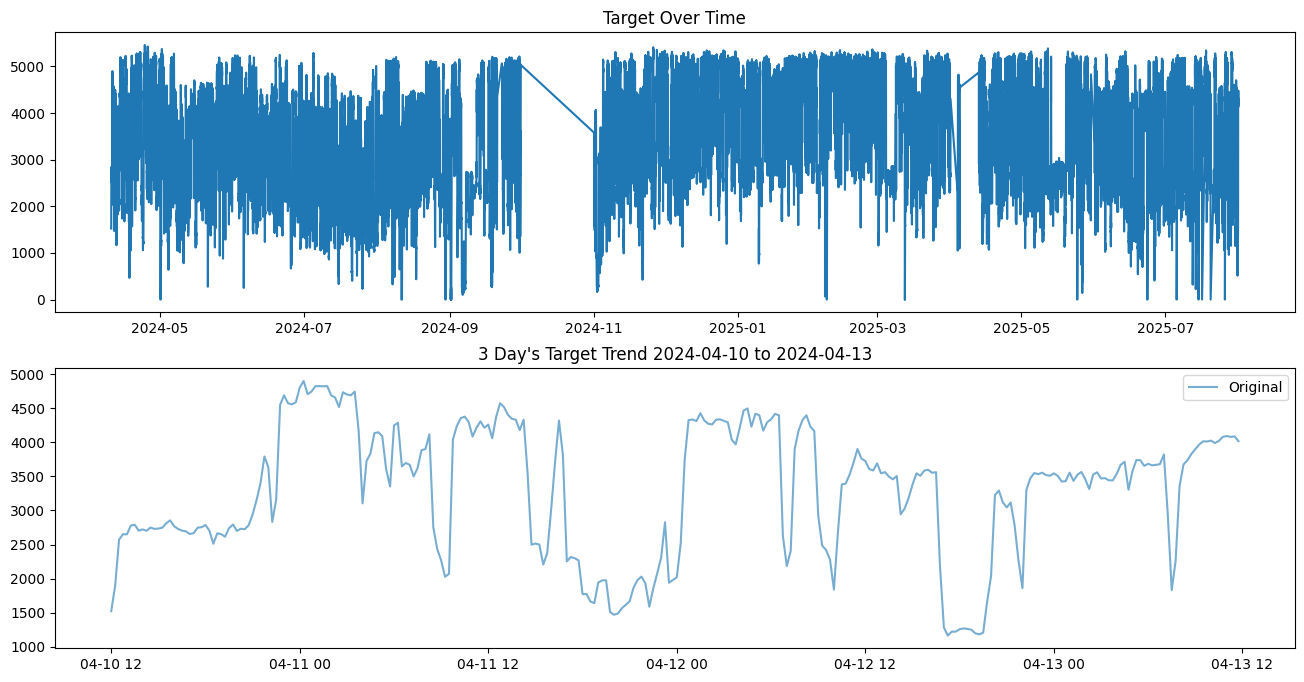

In [39]:
# Need to check Traget data from start to end time
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].plot(data['Time'],data['target'])

axes[0].set_title("Target Over Time")


one_week = data[data['Time'] < data['Time'].min() + pd.Timedelta(days=3)]
axes[1].plot(one_week['Time'],one_week['target'],alpha=0.6,label='Original')
axes[1].set_title("3 Day's Target Trend " + str(one_week['Time'].min().date()) + " to " + str(one_week['Time'].max().date()))
axes[1].legend()
plt.show()

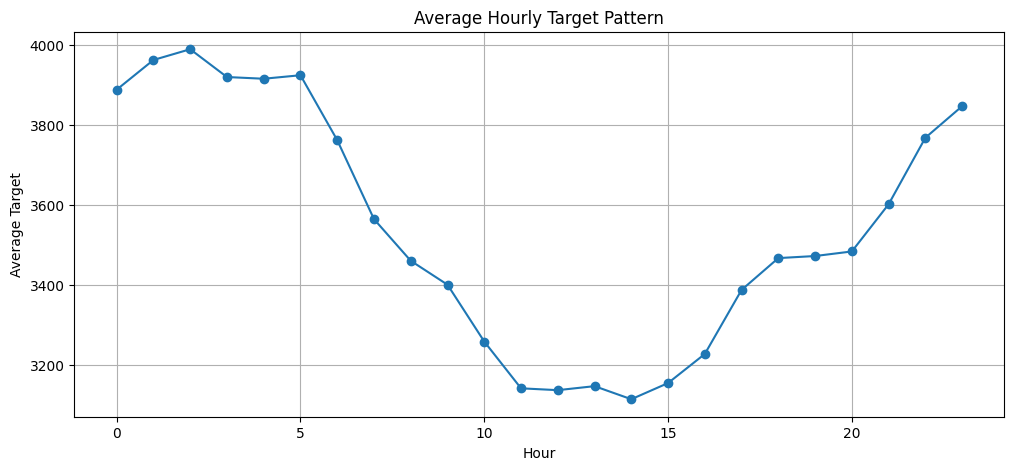

In [36]:
# Checking Hourly Seasonality patterns in the data

data['hour'] = data['Time'].dt.hour
hourly_pattern = (data.groupby('hour')['target'].mean())

plt.figure(figsize=(12,5))
plt.plot(hourly_pattern.index,hourly_pattern.values,marker='o')
plt.title("Average Hourly Target Pattern")
plt.xlabel("Hour")
plt.ylabel("Average Target")

plt.grid(True)
plt.show()

# Hourly Trend Analysis

Hour Range	Typical Behavior

0–5	    High demand

6–10    Falling

11–15   Lowest demand

16–23   Rising again

This is the GENERAL daily cycle learned from ALL data.

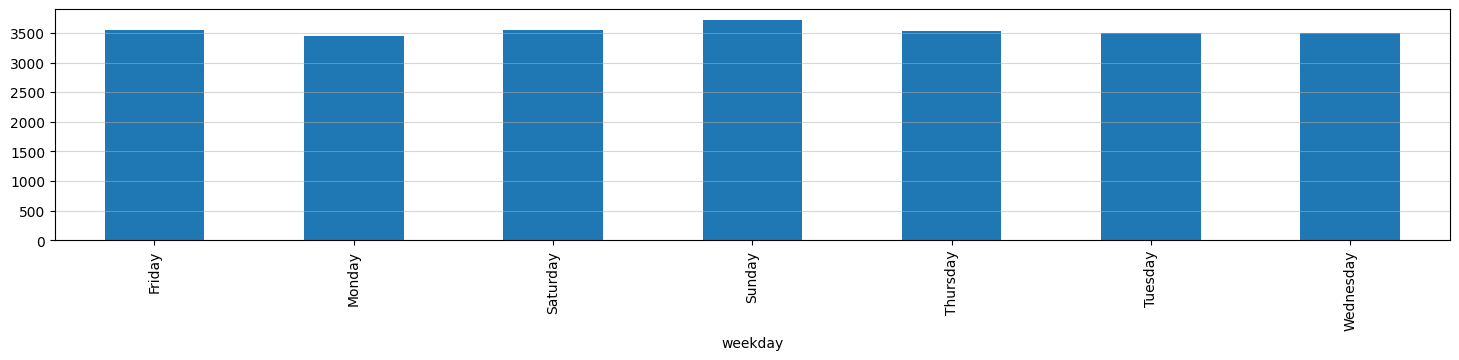

In [11]:
# Adding the Weekly Seasonality pattern in the data

data['weekday'] = data['Time'].dt.day_name()
weekly_pattern = (data.groupby('weekday')['target'].mean())

weekly_pattern.plot(kind='bar', figsize=(18,3))

plt.grid(True,axis='y',alpha=0.5)

# Feature Engineering
We transform:

Raw Data	 -> Smart ML Features

Time	     -> hour

Time     	 -> day_of_week

Time	     -> month

Past target	 -> lag features

Recent trend -> rolling mean

Cyclic time  -> sin/cos encoding

In [12]:
data_RF = data.copy()
data_RF.head()

,Time,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09,...,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,target,hour,weekday
0,2024-04-10 12:00:00,0.0,0.0,0.0,119.290878,0.0,0.0,108.502075,134.461426,100.306824,...,950.598267,317.534698,87.328026,908.293213,831.583679,1493.268188,728.515625,1522.5,12,Wednesday
1,2024-04-10 12:15:00,0.0,0.0,0.0,119.224632,0.0,0.0,0.173611,0.404006,0.115741,...,924.710449,219.791656,85.734978,44.133453,21.282021,0.000000,776.747009,1895.0,12,Wednesday
2,2024-04-10 12:30:00,0.0,0.0,0.0,119.294258,0.0,0.0,100.112236,109.554970,0.115741,...,923.986328,158.854156,88.341782,35.701073,644.438171,0.000000,748.914978,2572.5,12,Wednesday
3,2024-04-10 12:45:00,0.0,0.0,0.0,119.451820,0.0,0.0,95.328934,137.838760,70.482636,...,937.504272,179.861099,85.807388,280.516205,726.837707,0.000000,775.173645,2652.5,12,Wednesday
4,2024-04-10 13:00:00,0.0,0.0,0.0,119.407585,0.0,0.0,85.291878,144.616455,90.254265,...,949.533142,278.645813,84.866043,848.549438,815.185974,1540.173706,789.008301,2650.0,13,Wednesday


In [13]:
#  Time Features

#hourly pattern [0-23]
data_RF['hour'] = data_RF['Time'].dt.hour

#weekly pattern [Monday=0, Tuesday=1, Wednesday=2, Thursday=3, Friday=4, Saturday=5, Sunday=6]
data_RF['day_of_week'] = data_RF['Time'].dt.dayofweek


#Day of Month pattern [1-31]
data_RF['day_of_month'] = data_RF['Time'].dt.day

#month pattern [1-12]
data_RF['month'] = data_RF['Time'].dt.month

#quarterly pattern [1-4]
data_RF['quarter'] = data_RF['Time'].dt.quarter

#yearly pattern [2024-2025]
data_RF['year'] = data_RF['Time'].dt.year

#is_weekend pattern [0 for weekday, 1 for weekend] [Monday - Saturday = 0, Sunday = 1 ]
data_RF['is_weekend'] = (data_RF['day_of_week'] >= 5).astype(int)


# Cyclic Features

#hour_sin
data_RF['hour_sin'] = np.sin(2 * np.pi * data_RF['hour'] / 24)

#hour_cos
data_RF['hour_cos'] = np.cos(2 * np.pi * data_RF['hour'] / 24)


# Lag Features

# Lag 1
data_RF['target_lag_1'] = data_RF['target'].shift(1)

# Lag 2
data_RF['target_lag_2'] = data_RF['target'].shift(2)

#lag 3
data_RF['target_lag_3'] = data_RF['target'].shift(3)

#lag 4
data_RF['target_lag_4'] = data_RF['target'].shift(4)

# 1 Day Lag 15 min interval 24 * 4 = 96
data_RF['target_lag_96'] = data_RF['target'].shift(96)

#weekly lag 7 day lag 7 * 24 * 4 = 672
data_RF['target_lag_672'] = data_RF['target'].shift(672)

data_RF.head(5)


,Time,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09,...,year,is_weekend,hour_sin,hour_cos,target_lag_1,target_lag_2,target_lag_3,target_lag_4,target_lag_96,target_lag_672
0,2024-04-10 12:00:00,0.0,0.0,0.0,119.290878,0.0,0.0,108.502075,134.461426,100.306824,...,2024,0,1.224647e-16,-1.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-04-10 12:15:00,0.0,0.0,0.0,119.224632,0.0,0.0,0.173611,0.404006,0.115741,...,2024,0,1.224647e-16,-1.000000,1522.5,NaN,NaN,NaN,NaN,NaN
2,2024-04-10 12:30:00,0.0,0.0,0.0,119.294258,0.0,0.0,100.112236,109.554970,0.115741,...,2024,0,1.224647e-16,-1.000000,1895.0,1522.5,NaN,NaN,NaN,NaN
3,2024-04-10 12:45:00,0.0,0.0,0.0,119.451820,0.0,0.0,95.328934,137.838760,70.482636,...,2024,0,1.224647e-16,-1.000000,2572.5,1895.0,1522.5,NaN,NaN,NaN
4,2024-04-10 13:00:00,0.0,0.0,0.0,119.407585,0.0,0.0,85.291878,144.616455,90.254265,...,2024,0,-2.588190e-01,-0.965926,2652.5,2572.5,1895.0,1522.5,NaN,NaN


In [14]:
# Rolling Mean Features

#Rolling Mean 3
data_RF['target_rollmean_3'] = data_RF['target'].rolling(window=3).mean()

#Rolling Mean 24
data_RF['target_rollmean_24'] = data_RF['target'].rolling(window=24).mean()

#Daily Rolling Mean
data_RF['target_rollmean_96'] = data_RF['target'].rolling(window=96).mean()

#Rolling Standard Deviation
data_RF['target_rollstd_96'] = data_RF['target'].rolling(window=96).std()

data_RF.head(5).T

,0,1,2,3,4
Time,2024-04-10 12:00:00,2024-04-10 12:15:00,2024-04-10 12:30:00,2024-04-10 12:45:00,2024-04-10 13:00:00
feature_01,0.0,0.0,0.0,0.0,0.0
feature_02,0.0,0.0,0.0,0.0,0.0
feature_03,0.0,0.0,0.0,0.0,0.0
feature_04,119.290878,119.224632,119.294258,119.45182,119.407585
feature_05,0.0,0.0,0.0,0.0,0.0
feature_06,0.0,0.0,0.0,0.0,0.0
feature_07,108.502075,0.173611,100.112236,95.328934,85.291878
feature_08,134.461426,0.404006,109.55497,137.83876,144.616455
feature_09,100.306824,0.115741,0.115741,70.482636,90.254265


In [15]:
#removing rows with NaN values created by lag and rolling features
data_RF = data_RF.dropna().reset_index(drop=True)
print(data_RF.shape, data.shape)


(40280, 43) (40952, 25)


In [16]:
print(data_RF.columns)
print("NA values in data_RF:", data_RF.isnull().sum().sum())


Index(['Time', 'feature_01', 'feature_02', 'feature_03', 'feature_04',
       'feature_05', 'feature_06', 'feature_07', 'feature_08', 'feature_09',
       'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14',
       'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19',
       'feature_20', 'feature_21', 'target', 'hour', 'weekday', 'day_of_week',
       'day_of_month', 'month', 'quarter', 'year', 'is_weekend', 'hour_sin',
       'hour_cos', 'target_lag_1', 'target_lag_2', 'target_lag_3',
       'target_lag_4', 'target_lag_96', 'target_lag_672', 'target_rollmean_3',
       'target_rollmean_24', 'target_rollmean_96', 'target_rollstd_96'],
      dtype='str')
NA values in data_RF: 0


# model input now contains: -> Random Forest Training & Prediction

Information Type	     -> Example

Current sensor state	 -> feature_01

Current hour	         -> hour

Previous demand	         -> lag_1

Yesterday same time	     -> lag_96

Recent trend	         -> rolling mean

Volatility	             -> rolling std

In [17]:
#Training and Testing Data Split

X = data_RF.drop(['Time', 'target', 'weekday'],axis=1) # becaue Random Forest not consider the String data.
y = data_RF['target']
print(X.shape, y.shape)

(40280, 40) (40280,)


In [18]:
#Training  = 80% and Testing = 20%  Data Split 
split_index = int(len(data_RF) * 0.8)
X_train = X[:split_index]
y_train = y[:split_index]

X_test  = X[split_index:]
y_test  = y[split_index:]

print(f"X_train: {X_train.shape} \ny_train: {y_train.shape} \nX_test : {X_test.shape} \ny_test : {y_test.shape}")


X_train: (32224, 40) 
y_train: (32224,) 
X_test : (8056, 40) 
y_test : (8056,)


In [19]:
#Implementing Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=300,random_state=42,n_jobs=-1)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [20]:
#Testing the model
predictions = model.predict(X_test)
print(predictions.shape)


(8056,)


In [21]:
# prediction vs actual values
comparison = pd.DataFrame({'Actual': y_test.values,'Predicted': predictions})

print(comparison.head(10))

   Actual    Predicted
0  5215.0  5211.010000
1  4797.5  4850.350000
2  4582.5  4620.033333
3  4662.5  4667.233333
4  4660.0  4652.966667
5  4860.0  4870.608333
6  5072.5  5058.283333
7  5222.5  5137.616667
8  4860.0  4925.416667
9  5147.5  5062.975000


In [22]:
# MODEL EVALUATION and ACCURACY Detection

from sklearn.metrics import (r2_score,mean_absolute_error,mean_squared_error,mean_absolute_percentage_error)

mask = y_test != 0

mape = mean_absolute_percentage_error(y_test[mask],predictions[mask]) * 100
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test,predictions)
rmse = np.sqrt(mean_squared_error(y_test,predictions))



print(f"MAPE     : {mape:.2f}%")
print(f"R2 Score : {r2:.4f}")
print(f"MAE      : {mae:.2f}")
print(f"RMSE     : {rmse:.2f}")

MAPE     : 1.89%
R2 Score : 0.9930
MAE      : 46.20
RMSE     : 103.25


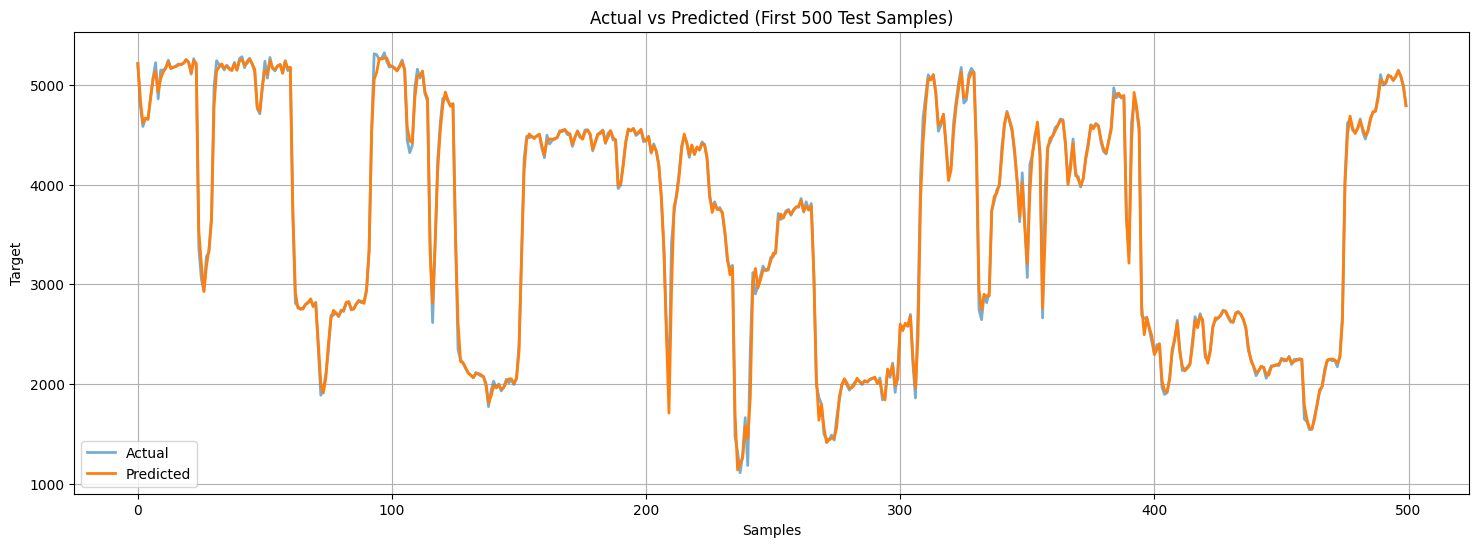

In [23]:
#actual vs predicted values in visual plotting

plt.figure(figsize=(18,6))

plt.plot(y_test.values[:500],label='Actual',linewidth=2,alpha=0.6)

plt.plot(predictions[:500],label='Predicted',linewidth=2)

plt.title('Actual vs Predicted (First 500 Test Samples)')
plt.xlabel('Samples')
plt.ylabel('Target')
plt.legend()
plt.grid(True)

plt.show()

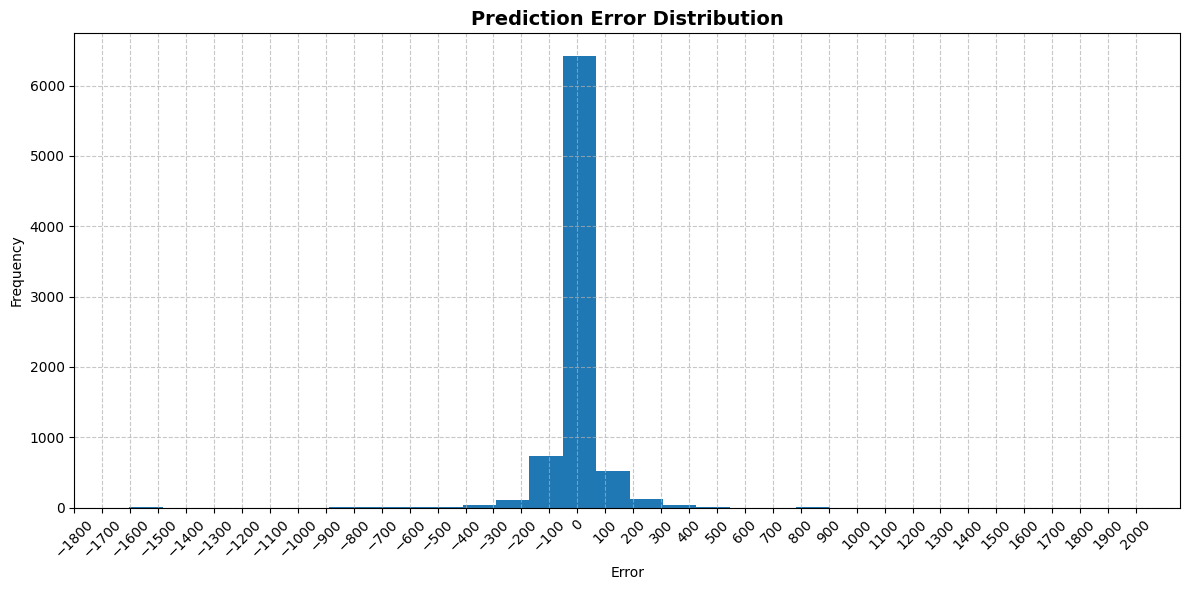

In [24]:
# Error Distribution Detection

errors = y_test.values - predictions

plt.figure(figsize=(12,6))

# Histogram
plt.hist(errors,bins=30)
plt.title('Prediction Error Distribution',fontsize=14,fontweight='bold')
plt.xlabel('Error')
plt.ylabel('Frequency')

# X-axis ticks every 100
plt.xticks(np.arange(-1800, int(errors.max()) + 100, 100), rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

# Future data ploting and analysis

In [25]:
future_data = data_RF.copy()
history_targets = list(future_data['target'].values)

#last row of the data frame for future prediction
last_row = future_data.iloc[-1:].copy()
feature_columns = X.columns.tolist()

future_predictions = []
future_times = []

forecast_steps = 96


In [26]:
# =====================================
# Predict
# =====================================

pred = model.predict(last_row[feature_columns])[0]

# =====================================
# Store prediction
# =====================================

future_predictions.append(pred)

history_targets.append(pred)

# =====================================
# Next timestamp
# =====================================

next_time = pd.to_datetime(last_row['Time'].values[0]) + pd.Timedelta(minutes=15)

future_times.append(next_time)

# =====================================
# Create new row
# =====================================

new_row = last_row.copy()

# =====================================
# Update Time & Target
# =====================================

new_row['Time'] = next_time

new_row['target'] = pred

# =====================================
# Time Features
# =====================================

new_row['hour'] = next_time.hour

new_row['day_of_week'] = next_time.dayofweek

new_row['day_of_month'] = next_time.day

new_row['month'] = next_time.month

new_row['quarter'] = next_time.quarter

new_row['year'] = next_time.year

new_row['is_weekend'] = int(next_time.dayofweek >= 5)

# =====================================
# Cyclic Features
# =====================================

new_row['hour_sin'] = np.sin(2 * np.pi * new_row['hour'] / 24)

new_row['hour_cos'] = np.cos(2 * np.pi * new_row['hour'] / 24)

# =====================================
# Lag Features
# =====================================

new_row['target_lag_1'] = history_targets[-1]

new_row['target_lag_2'] = history_targets[-2]

new_row['target_lag_3'] = history_targets[-3]

new_row['target_lag_4'] = history_targets[-4]

new_row['target_lag_96'] = history_targets[-96]

new_row['target_lag_672'] = history_targets[-672]

# =====================================
# Rolling Features
# =====================================

new_row['target_rollmean_3'] = np.mean(history_targets[-3:])

new_row['target_rollmean_24'] = np.mean(history_targets[-24:])

new_row['target_rollmean_96'] = np.mean(history_targets[-96:])

new_row['target_rollstd_96'] = np.std(history_targets[-96:])

# =====================================
# Move forward
# =====================================

last_row = new_row.copy()

In [27]:
future_table = pd.DataFrame({
    'Future_Time': future_times,
    'Predicted_Target': future_predictions
})

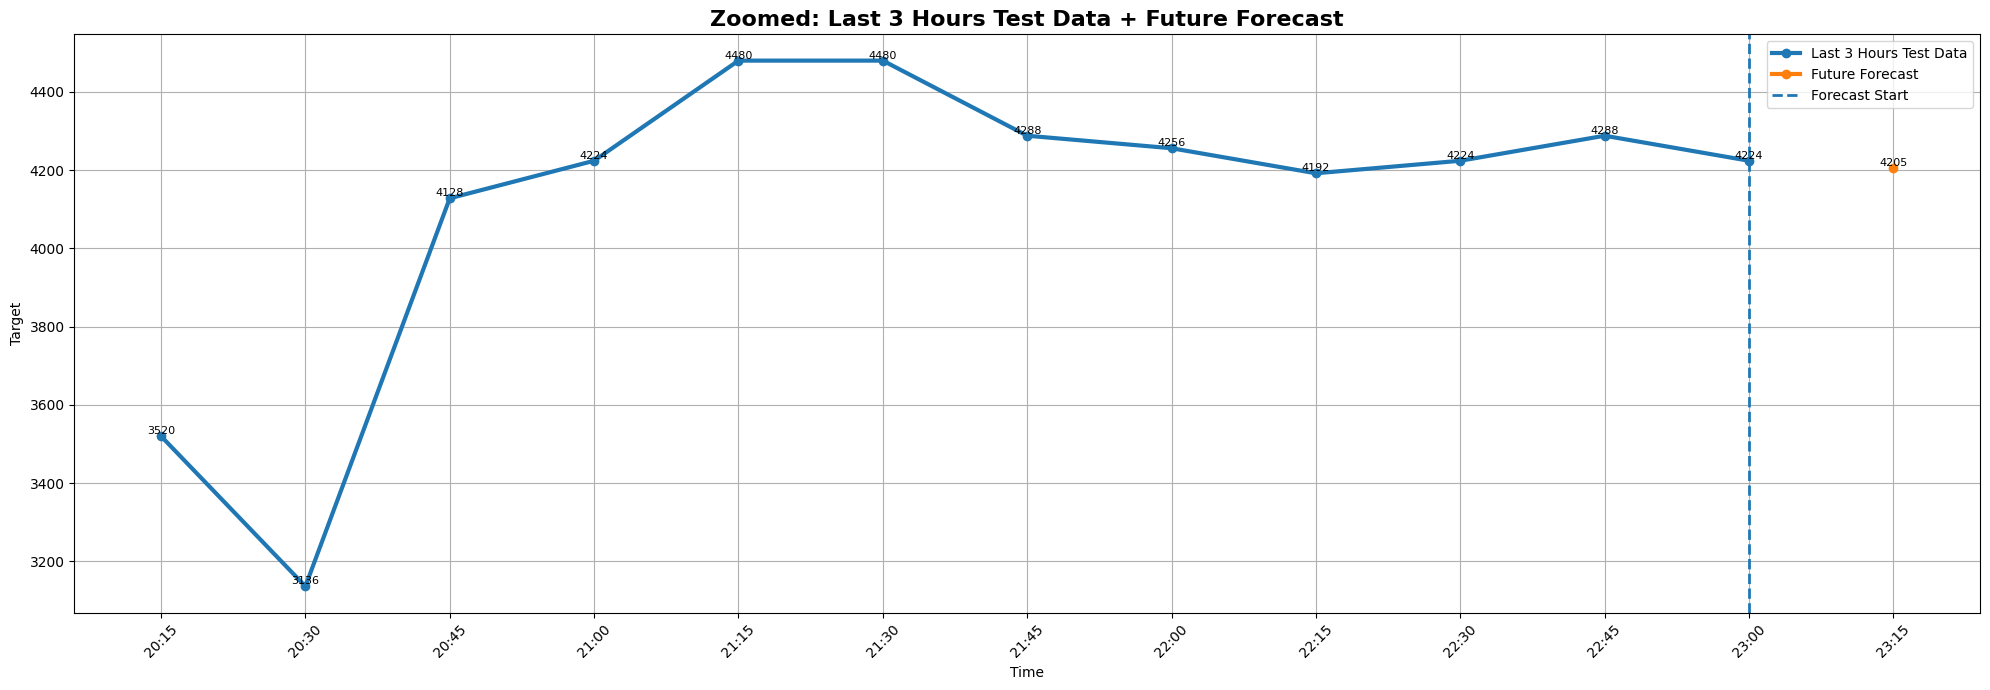

In [28]:
# Last 3 Hours Test Data + Future Forecast with Data Labels

plt.figure(figsize=(20,7))

# Last 3 Hours Test Data
test_zoom = y_test.values[-12:]

# Plot test data
plt.plot(range(len(test_zoom)),test_zoom,label='Last 3 Hours Test Data',linewidth=3,marker='o')

# Add REAL DATA LABELS

for i,value in enumerate(test_zoom):
    plt.text(i,value,f'{value:.0f}',fontsize=8,ha='center',va='bottom')

# Future X-axis

future_x = np.arange(len(test_zoom),len(test_zoom) + len(future_predictions))

# Plot Future Forecast

plt.plot(future_x,future_predictions,label='Future Forecast',linewidth=3,marker='o')

for x,value in zip(future_x,future_predictions):
    plt.text(x,value,f'{value:.0f}',fontsize=8,ha='center',va='bottom')

plt.axvline(x=len(test_zoom)-1,linestyle='--',linewidth=2,label='Forecast Start')


x_labels = []
test_times = data_RF['Time'].iloc[-12:]

for t in test_times:
    x_labels.append(pd.to_datetime(t).strftime('%H:%M'))

# Future timestamps
for t in future_times:
    x_labels.append(pd.to_datetime(t).strftime('%H:%M'))

# Apply labels
plt.xticks(range(len(x_labels)),x_labels,rotation=45)


plt.title('Zoomed: Last 3 Hours Test Data + Future Forecast',fontsize=16,fontweight='bold')
plt.xlabel('Time')
plt.ylabel('Target')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [29]:
# Correlation of Feature that importance in the Random Forest Model

corr_matrix = data_RF.corr(numeric_only=True)
target_corr = corr_matrix['target'].sort_values(ascending=False)
print(target_corr)

target                1.000000
target_rollmean_3     0.970497
target_lag_1          0.952988
target_lag_2          0.892596
target_lag_3          0.842808
target_lag_4          0.802609
feature_02            0.762265
feature_01            0.754042
feature_06            0.753972
target_rollmean_24    0.737713
feature_03            0.715697
feature_05            0.670565
target_rollmean_96    0.508463
feature_20            0.360154
feature_12            0.352064
feature_15            0.349402
feature_14            0.341701
feature_07            0.319466
feature_13            0.316680
feature_08            0.306883
feature_09            0.287790
target_lag_96         0.282244
feature_21            0.259245
feature_16            0.256331
feature_18            0.231998
feature_10            0.229810
hour_cos              0.216422
year                  0.205236
target_lag_672        0.200151
feature_17            0.186116
feature_19            0.178176
hour_sin              0.095854
day_of_m

    
    ∑(xi​−xˉ)2∑(yi​−yˉ​)2
 r= -------------------
 
    ​∑(xi​−xˉ)(yi​−yˉ​)​

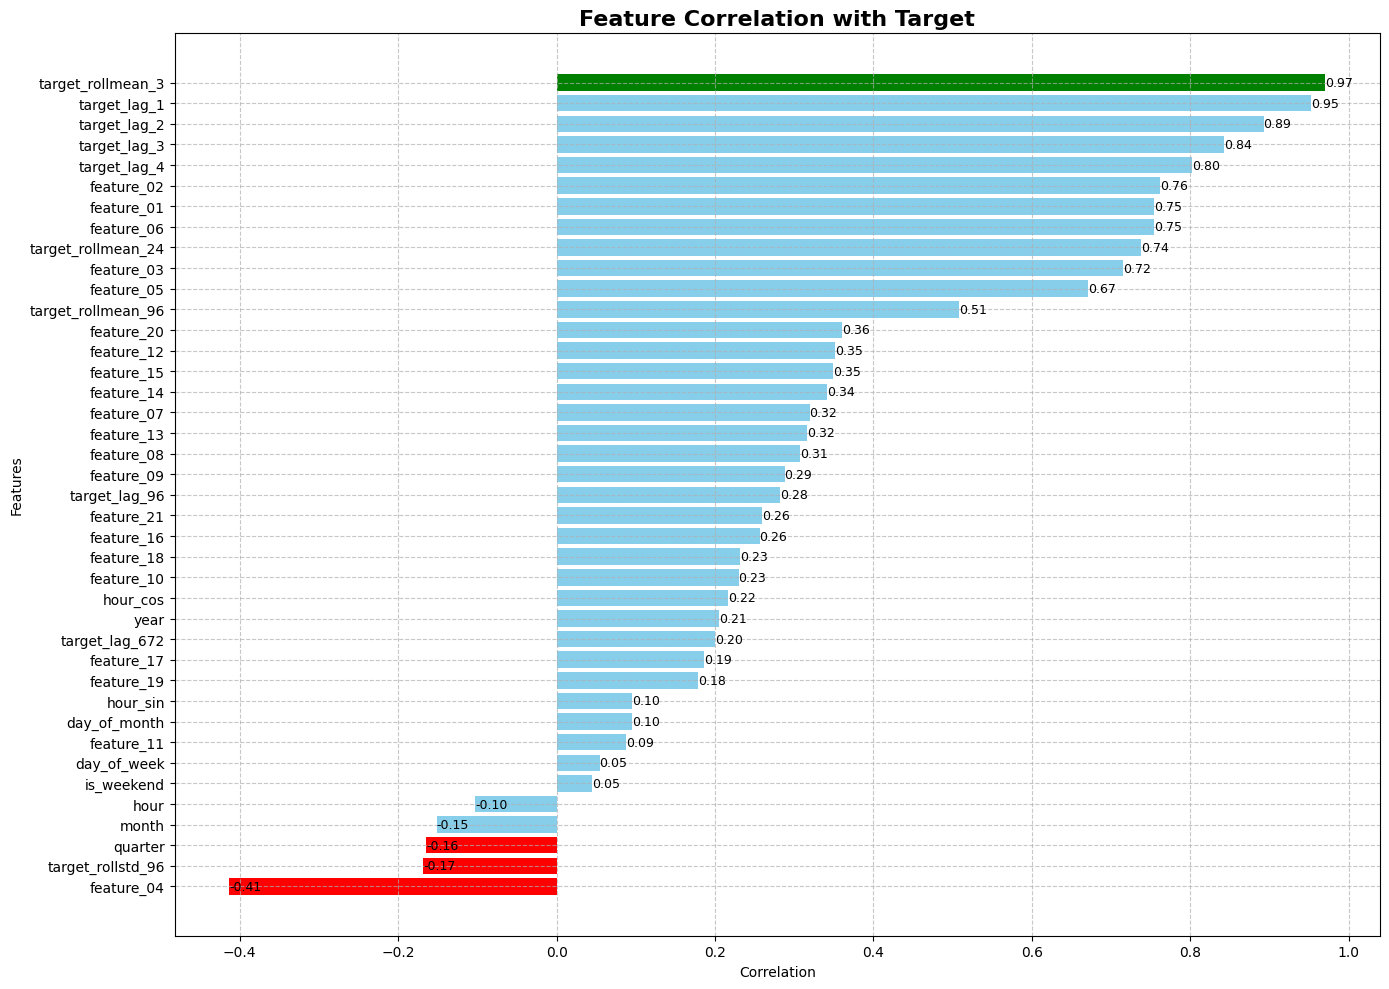

In [30]:
# Remove self-correlation
target_corr = target_corr.drop('target')

# Sort values
sorted_corr = target_corr.sort_values()

# Create Colors


colors = ['skyblue'] * len(sorted_corr)
# Highest correlation -> GREEN
colors[-1] = 'green'
# Last 3 lowest correlations -> RED
colors[0] = 'red'
colors[1] = 'red'
colors[2] = 'red'

plt.figure(figsize=(14,10))

bars = plt.barh(sorted_corr.index,sorted_corr.values,color=colors)


for bar,value in zip(bars,sorted_corr.values):
    plt.text(bar.get_width(),bar.get_y() + bar.get_height()/2,f'{value:.2f}',va='center',fontsize=9)



plt.title('Feature Correlation with Target',fontsize=16,fontweight='bold')
plt.xlabel('Correlation')
plt.ylabel('Features')
plt.grid(True,linestyle='--',alpha=0.7)
plt.tight_layout()

plt.show()

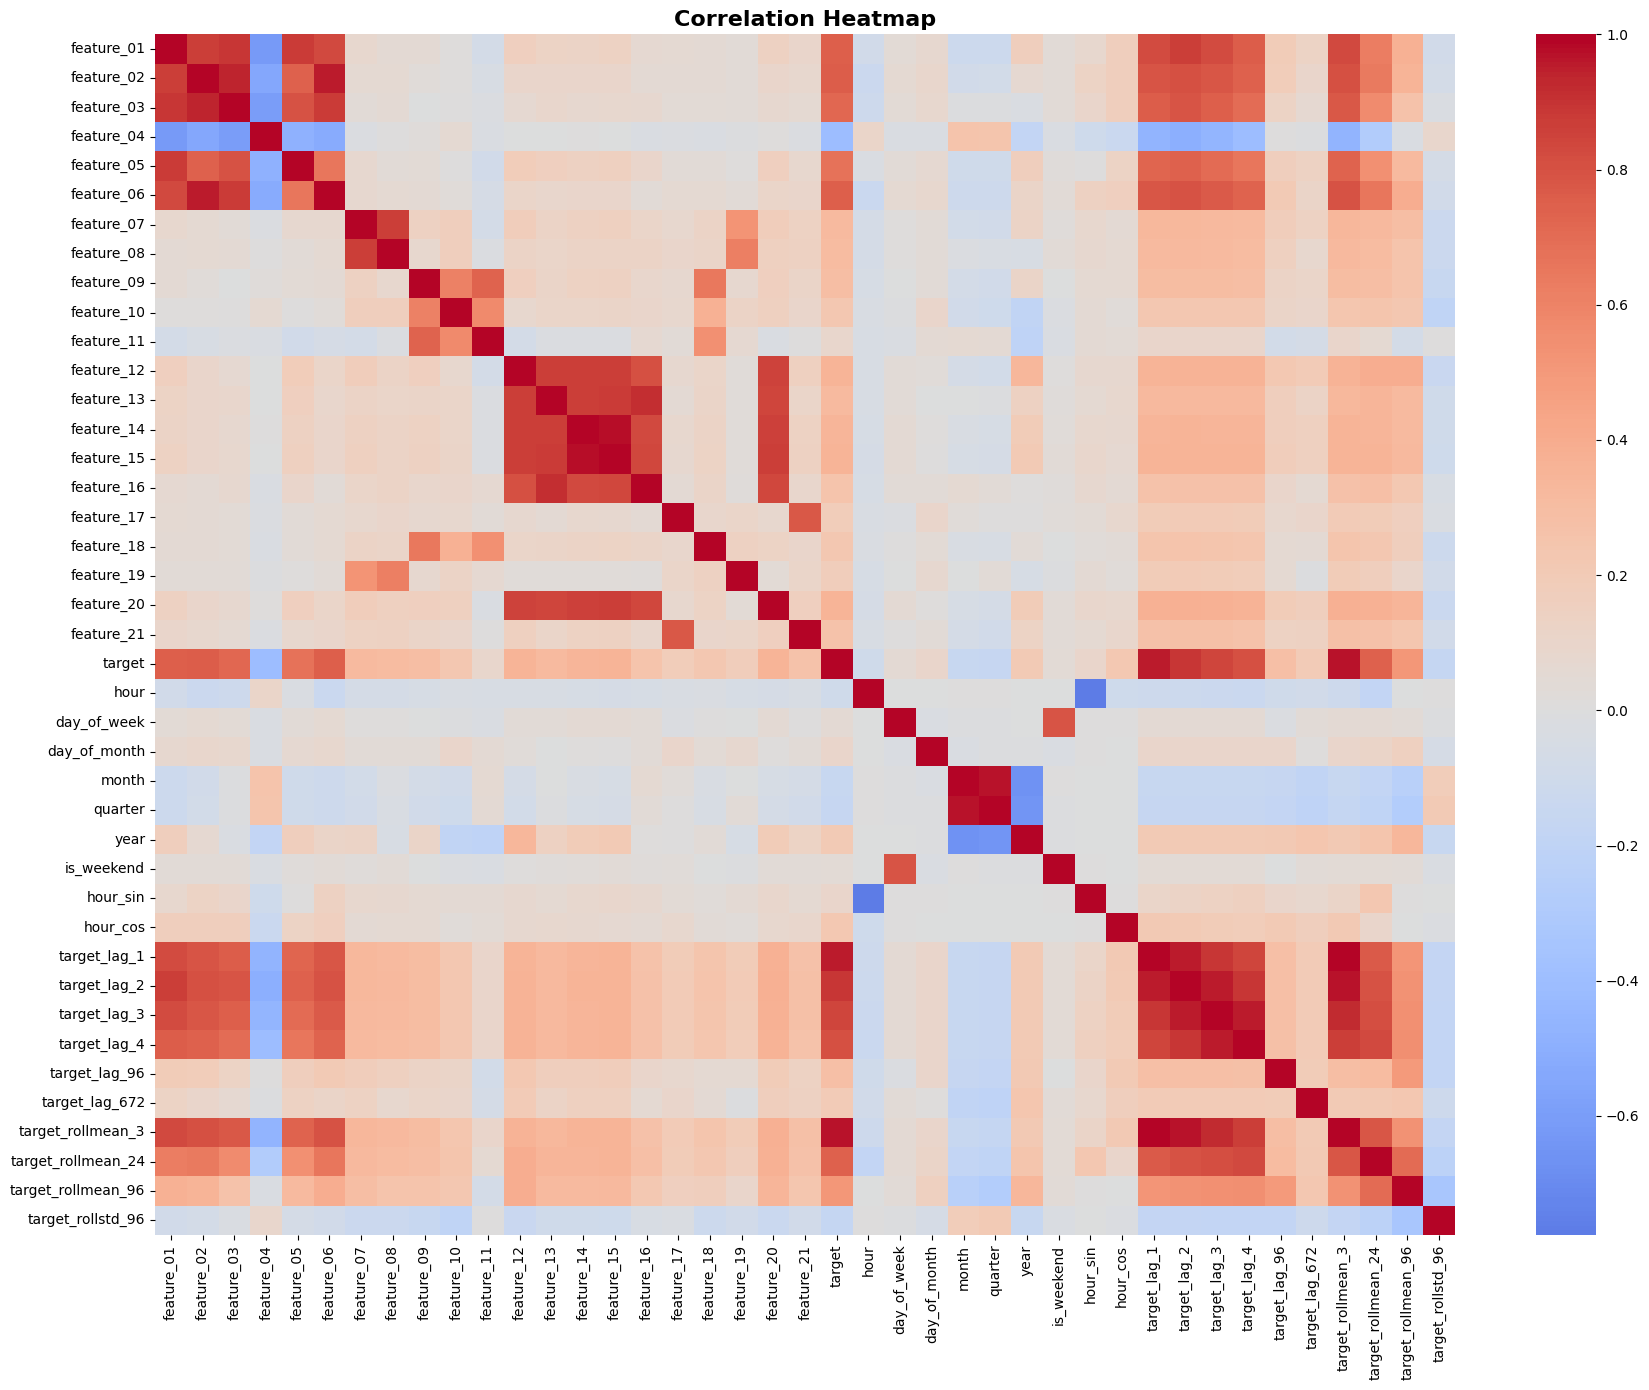

In [31]:
import seaborn as sns

plt.figure(figsize=(18,14))
sns.heatmap(corr_matrix,cmap='coolwarm',center=0)
plt.title('Correlation Heatmap',fontsize=16,fontweight='bold')
plt.tight_layout()

plt.show()